## Project overview
 There ia a project from video streaming company. This company recently lossing more customers. The stakeholders have decided to use data science to khow the reason and figure out the solution.

## 1. Define Scope of the project
#### Problem statement:
A video streming company is experiencing a decline in premium subscription, with significant number of customers canceling their subscription plans. The goal is to understand the factors contributing customers churn and develop strategies.

#### Objective and Goals
Analyze customer behaviour and usage pattern to identify main factors contributing customers churn

#### Data requirements
Gender and demographic = Age, sex, location
Usage = How much time they have spent, what are they search, how much time they spent on each video, how many times they open the app in a day (daily active users)
Subscription plan: How frequent they purchase the plan, how many times they come to the subscription landing page
Engagement with add-ons

In [1]:
# import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(".//Streaming.csv")
df.sample(5)

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
3182,CUST003183,69.0,Male,17,North,Debit Card,0,10.0,19.77,159,59.60,0
1103,CUST001104,53.0,Male,32,East,Debit Card,2,7.0,8.89,314,49.66,1
4290,CUST004291,58.0,Female,11,East,Credit Card,2,4.0,6.99,69,34.35,0
3773,CUST003774,21.0,Female,17,South,Debit Card,1,7.0,6.51,255,44.09,0
3919,CUST003920,54.0,Male,19,West,Debit Card,1,9.0,7.50,263,50.68,0


### Remove the features from dataset which are not important

In [3]:
df.drop(columns=['Subscription_Length','Payment_Method'], inplace=True)
df.sample(5)

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
2148,CUST002149,32.0,Female,North,2,NaN,12.58,258,54.97,0
1912,CUST001913,39.0,Male,East,4,5.0,16.37,81,42.86,0
233,CUST000234,49.0,Female,South,1,8.0,6.32,336,48.50,1
1444,CUST001445,35.0,Male,East,4,9.0,14.91,217,48.57,0
3889,CUST003890,NaN,Male,North,3,4.0,15.62,352,44.51,1


### Undersatnd the features datatypes

In [4]:
df.dtypes

Customer_ID                   str
Age                       float64
Gender                        str
Region                        str
Support_Tickets_Raised      int64
Satisfaction_Score        float64
Discount_Offered          float64
Last_Activity               int64
Monthly_Spend             float64
Churned                     int64
dtype: object

1). Change datatype 62-bit to 32-bit where is possible because it consume less resources

## Make decision remove or impute missing values

In [5]:
df.isna().sum()

Customer_ID                 0
Age                       500
Gender                      0
Region                      0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

In [6]:
# percentage of missing columns
df.isna().mean()*100

Customer_ID                0.0
Age                       10.0
Gender                     0.0
Region                     0.0
Support_Tickets_Raised     0.0
Satisfaction_Score        10.0
Discount_Offered           0.0
Last_Activity              0.0
Monthly_Spend              0.0
Churned                    0.0
dtype: float64

check the percentage of missing values is greater than 5-percentage than not delete values

### Imputation

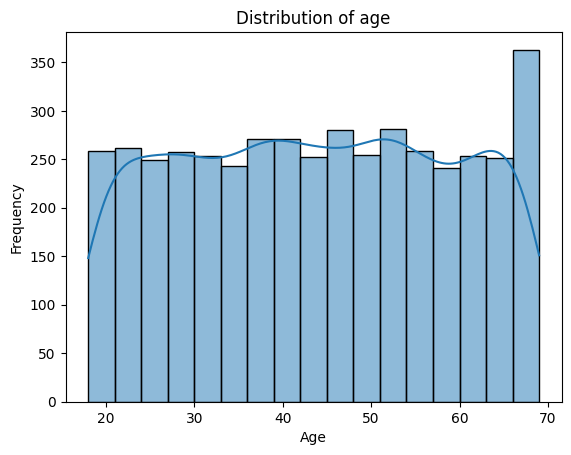

In [7]:
### Check distribution is normal distribution or not
sns.histplot(data=df, kde=True, x=df['Age'].dropna())
plt.title("Distribution of age")
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Decision 
hence distribution is multimodel hence use knn or mice imputers

### KNN INputer vis scikit learn

In [8]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df['Age'] = imputer.fit_transform(df[['Age']])

In [9]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
df.isna().sum()

Customer_ID                 0
Age                         0
Gender                      0
Region                      0
Support_Tickets_Raised      0
Satisfaction_Score        500
Discount_Offered            0
Last_Activity               0
Monthly_Spend               0
Churned                     0
dtype: int64

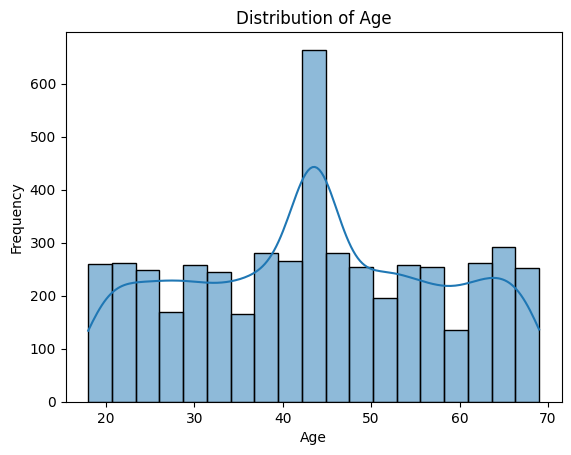

In [11]:
sns.histplot(data=df,kde=True,x=df['Age'])
plt.title("Distribution of Age")
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [34]:
df.head()
df['Satisfaction_Score'].value_counts()

Satisfaction_Score
6.0     477
4.0     469
10.0    466
7.0     463
1.0     449
8.0     448
9.0     443
2.0     439
5.0     436
3.0     407
Name: count, dtype: int64

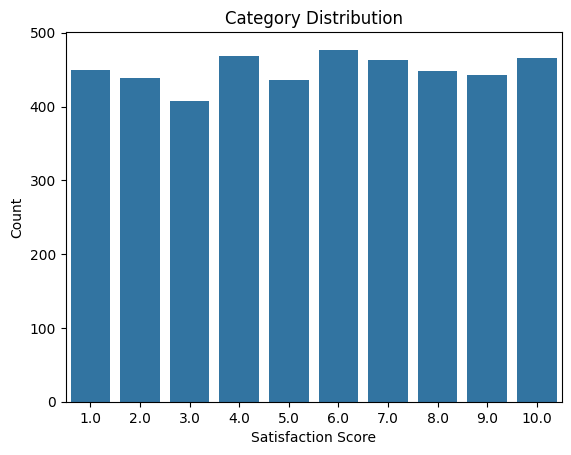

In [35]:
# visualize the discreate numerical column 
sns.countplot(x=df['Satisfaction_Score'].dropna(), data=df)
plt.title("Category Distribution")
plt.xlabel('Satisfaction Score')
plt.ylabel('Count')
plt.show()

In [36]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent') # mode imputation
df[['Satisfaction_Score']] = imputer.fit_transform(df[['Satisfaction_Score']])

### Using Mice imputer

In [37]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer()
df[['Age']] = imputer.fit_transform(df[['Age']])

### Data Cleaning
.Remove typos, duplicates, inconsistencies from data

In [38]:
df.sample(5)

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
2268,CUST002269,54.000000,Female,South,3,6.0,16.84,289,56.07,0
889,CUST000890,44.000000,Female,West,1,3.0,15.40,215,37.73,1
3427,CUST003428,63.000000,Male,South,1,5.0,15.90,320,43.29,1
1102,CUST001103,43.582222,Male,East,1,5.0,10.83,34,42.97,0
4086,CUST004087,43.582222,Female,South,3,6.0,14.42,62,50.04,0


In [39]:
df['Gender'].value_counts()

Gender
Female    2513
Male      2484
Name: count, dtype: int64

In [40]:
df['Region'].value_counts()

Region
West     1316
North    1243
South    1237
East     1201
Name: count, dtype: int64

In [41]:
df.describe()

,Age,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000
mean,43.585173,2.037022,5.590955,12.461043,181.490294,46.587478,0.448069
std,14.203213,1.422409,2.724540,4.324474,104.511149,9.314743,0.497346
min,18.000000,0.000000,1.000000,5.000000,1.000000,21.770000,0.000000
25%,32.000000,1.000000,3.000000,8.700000,90.000000,39.890000,0.000000
50%,43.582222,2.000000,6.000000,12.500000,182.000000,46.610000,0.000000
75%,55.000000,3.000000,8.000000,16.190000,271.000000,53.200000,1.000000
max,69.000000,9.000000,10.000000,20.000000,364.000000,70.000000,1.000000


In [42]:
df[df['Monthly_Spend'] > 0]['Monthly_Spend'].min()

np.float64(21.77)

In [43]:
min_monthly_spend = df[df['Monthly_Spend'] > 0]['Monthly_Spend'].min()
df['Monthly_Spend'] = np.where(df['Monthly_Spend'] < 0, min_monthly_spend, df['Monthly_Spend'])


In [44]:
df.describe()

,Age,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
count,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000
mean,43.585173,2.037022,5.590955,12.461043,181.490294,46.587478,0.448069
std,14.203213,1.422409,2.724540,4.324474,104.511149,9.314743,0.497346
min,18.000000,0.000000,1.000000,5.000000,1.000000,21.770000,0.000000
25%,32.000000,1.000000,3.000000,8.700000,90.000000,39.890000,0.000000
50%,43.582222,2.000000,6.000000,12.500000,182.000000,46.610000,0.000000
75%,55.000000,3.000000,8.000000,16.190000,271.000000,53.200000,1.000000
max,69.000000,9.000000,10.000000,20.000000,364.000000,70.000000,1.000000


## Detect Outliers

In [45]:
df.head()

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,South,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,East,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,East,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,West,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,East,2,6.0,13.18,65,45.97,0


In [46]:
df['Discount_Offered'].describe()

count    4997.000000
mean       12.461043
std         4.324474
min         5.000000
25%         8.700000
50%        12.500000
75%        16.190000
max        20.000000
Name: Discount_Offered, dtype: float64

<Axes: xlabel='Discount_Offered', ylabel='Density'>

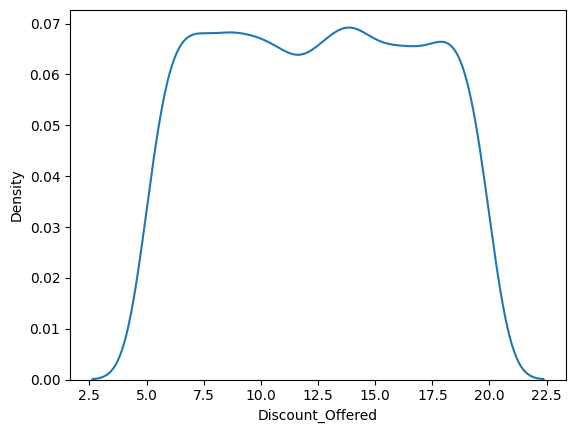

In [47]:
sns.kdeplot(x=df['Discount_Offered'], data= df)

In [48]:
df['Monthly_Spend'].describe()

count    4997.000000
mean       46.587478
std         9.314743
min        21.770000
25%        39.890000
50%        46.610000
75%        53.200000
max        70.000000
Name: Monthly_Spend, dtype: float64

<Axes: xlabel='Monthly_Spend', ylabel='Density'>

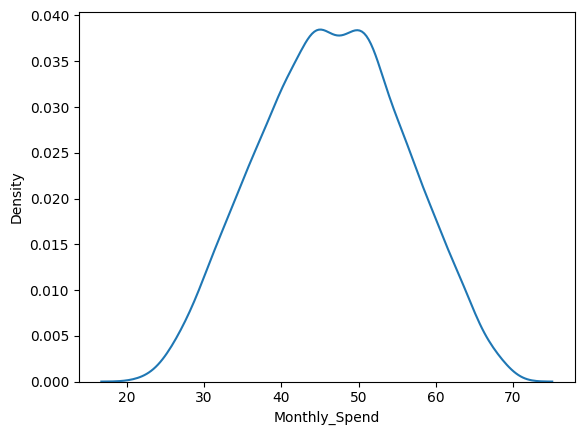

In [49]:
sns.kdeplot(data=df, x=df["Monthly_Spend"])

In [50]:
df[df['Monthly_Spend'] > 75]

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned


In [51]:
mean = df['Monthly_Spend'].mean()
std = df['Monthly_Spend'].std()

upper_bound = mean + 3*std
lower_bound = mean - 3*std

within_3rd_std = df[(df['Monthly_Spend'] >= lower_bound) & (df['Monthly_Spend'] <= upper_bound)]

# count and percentage 
count_within = within_3rd_std.shape[0]
total_count = df.shape[0]

percentage = (count_within / total_count) * 100

percentage

100.0

In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

month_spend_scaled = scaler.fit_transform(df[['Monthly_Spend']])

mask = np.abs(month_spend_scaled) < 3

df = df[mask.flatten()]

In [53]:
df[df['Monthly_Spend'] > 75]

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned


<Axes: xlabel='Monthly_Spend', ylabel='Density'>

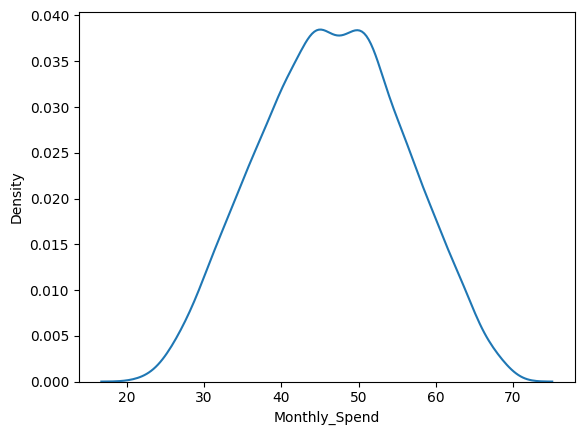

In [54]:
sns.kdeplot(x=df['Monthly_Spend'],data=df)

### EDA
Try to better understand the customers who cancelled:
* What percentage of customers who cancelled had a discount vs customers who didn't cancel?
* What is the average satisfaction score of customers who cancelled
* What percentage of male and female customers who cancelled the subscription
* How many support ticket raised by customers who cancelled vs who don't
* What is the relation between monthly spend and last activity - customers get their ROI
* In which Region the cancellation is much higher

In [55]:
df.head()

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,South,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,East,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,East,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,West,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,East,2,6.0,13.18,65,45.97,0


In [56]:
df.isna().mean()*100

Customer_ID               0.0
Age                       0.0
Gender                    0.0
Region                    0.0
Support_Tickets_Raised    0.0
Satisfaction_Score        0.0
Discount_Offered          0.0
Last_Activity             0.0
Monthly_Spend             0.0
Churned                   0.0
dtype: float64

In [57]:
# view customers who cancelled and the discount offered is less than 10%
df[(df['Churned'] == 1) & (df['Discount_Offered'] < 10)].shape[0]

741

In [58]:
# view customers who did not cancel the subscription and the discount offered is less than 10%
df[(df['Churned'] == 0) & (df['Discount_Offered'] < 10)].shape[0]

949

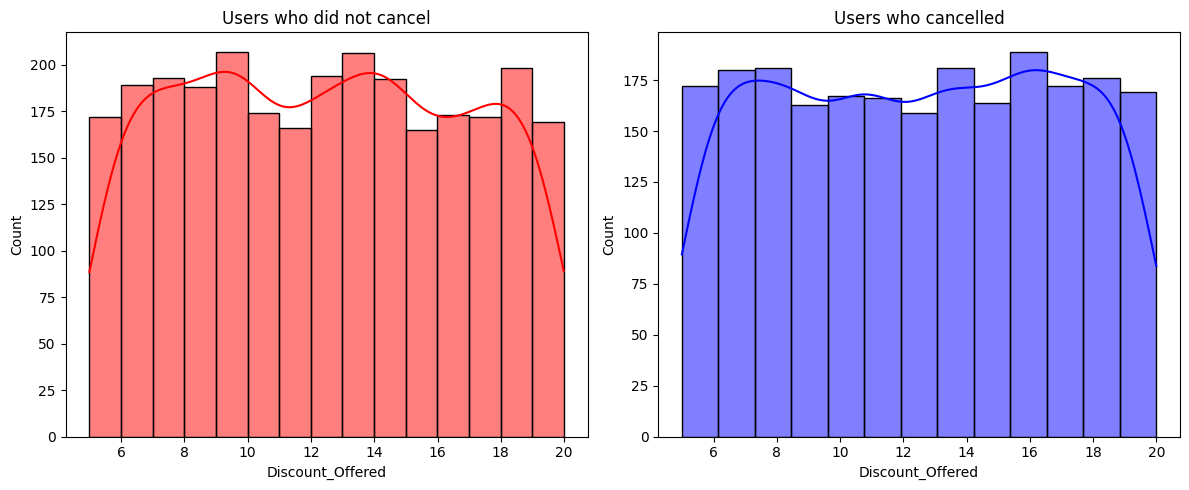

In [59]:
users_df = df[df['Churned'] == 0]['Discount_Offered']
cancelled_users_df = df[df['Churned'] == 1]['Discount_Offered']

fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.histplot(x=users_df, data=df,ax=axes[0], kde=True, color='r')
axes[0].set_title('Users who did not cancel')

sns.histplot(x=cancelled_users_df, data=df,ax=axes[1], kde=True, color='b')
axes[1].set_title('Users who cancelled')

plt.tight_layout()
plt.show()

### discount is not main factor for cancellation

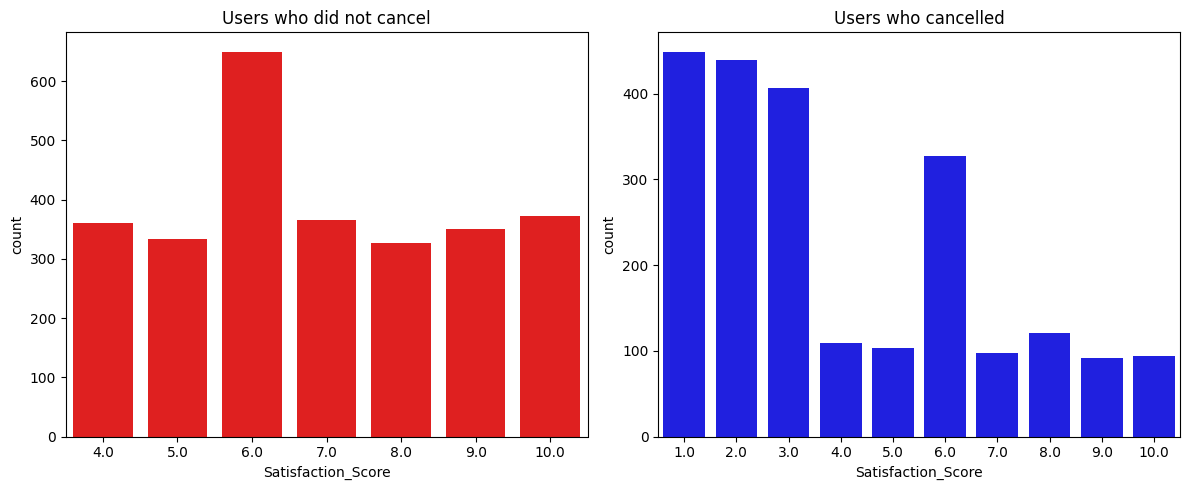

In [60]:
users_df = df[df['Churned'] == 0]['Satisfaction_Score']
cancelled_users_df = df[df['Churned'] == 1]['Satisfaction_Score']

fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.countplot(x=users_df, data=df,ax=axes[0],color='r')
axes[0].set_title('Users who did not cancel')

sns.countplot(x=cancelled_users_df, data=df,ax=axes[1],color='b')
axes[1].set_title('Users who cancelled')

plt.tight_layout()
plt.show()

In [61]:
df[df['Churned'] == 1]['Satisfaction_Score'].mean()

np.float64(3.9673961589995534)

In [62]:
df[df['Churned'] == 0]['Satisfaction_Score'].mean()

np.float64(6.908992023205221)

### its clearly sees that customers who canceled is not satiesfied with platform

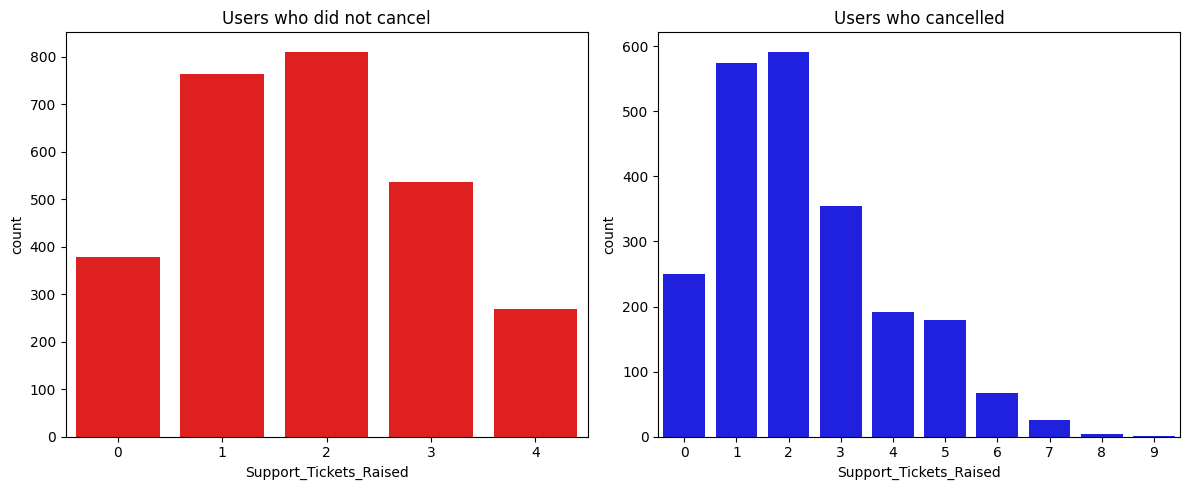

In [63]:
users_df = df[df['Churned'] == 0]['Support_Tickets_Raised']
cancelled_users_df = df[df['Churned'] == 1]['Support_Tickets_Raised']

fig, axes = plt.subplots(1,2,figsize=(12,5))

sns.countplot(x=users_df, data=df,ax=axes[0],color='r')
axes[0].set_title('Users who did not cancel')

sns.countplot(x=cancelled_users_df, data=df,ax=axes[1],color='b')
axes[1].set_title('Users who cancelled')

plt.tight_layout()
plt.show()

### Summary: Support ticket is not the factor for cancellation

### Conclusion
- Most customers who cancelled their subscriptions did so because they weren’t happy with the platform. They gave low ratings before leaving, which shows they were not satisfied
- Things like discounts, gender, region, or subscription price don’t seem to be the reason for cancellation.
- The real issue might be poor content—like bad movies or low-quality audio—but this kind of feedback isn’t included in the dataset.

### Feature Engineering

In [64]:
df.head()

,Customer_ID,Age,Gender,Region,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,South,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,East,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,East,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,West,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,East,2,6.0,13.18,65,45.97,0


In [65]:
# necessary for training purposes
df.drop(columns=['Customer_ID'], inplace=True)

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Step 2: Split features and target
X = df.drop('Churned', axis=1)
y = df['Churned']

# Step 3: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Define preprocessing
numeric_features = ['Age', 'Support_Tickets_Raised', 'Satisfaction_Score',
                    'Discount_Offered', 'Last_Activity', 'Monthly_Spend']
categorical_features = ['Gender', 'Region']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# Step 5: Create pipeline
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor)
])

# Step 6: Transform the data
X_train_transformed = pipeline.fit_transform(X_train)
X_test_transformed = pipeline.transform(X_test)

# Output shapes and preview
print("Transformed training shape:", X_train_transformed)
print("Transformed test shape:", X_test_transformed)

Transformed training shape: [[ 1.58150715  0.66514839  0.88932384 ...  1.          0.
   0.        ]
 [ 0.1044449  -0.7264235   0.15671308 ...  0.          1.
   0.        ]
 [-0.1769003  -0.03063756  1.25562921 ...  1.          0.
   0.        ]
 ...
 [-1.09127216 -0.03063756  1.25562921 ...  0.          0.
   0.        ]
 [ 0.24511749 -0.03063756  1.62193459 ...  0.          0.
   1.        ]
 [ 0.00472366 -0.03063756 -0.57589767 ...  0.          0.
   1.        ]]
Transformed test shape: [[-1.30228106 -0.7264235  -0.94220305 ...  0.          0.
   0.        ]
 [ 0.52646268  0.66514839 -0.94220305 ...  0.          1.
   0.        ]
 [ 0.00472366 -0.03063756  0.88932384 ...  0.          0.
   0.        ]
 ...
 [-0.95059957 -0.03063756 -0.20959229 ...  1.          0.
   0.        ]
 [ 0.45612638 -0.03063756  1.62193459 ...  0.          0.
   0.        ]
 [-1.51328995 -0.7264235   0.15671308 ...  0.          0.
   0.        ]]
